In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/customer churn'))

['Churn_Modelling.csv']


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/customer churn/Churn_Modelling.csv'

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Basic dataset information

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["Exited"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing Values:
RowNumber          0
CustomerId         0
Surname       

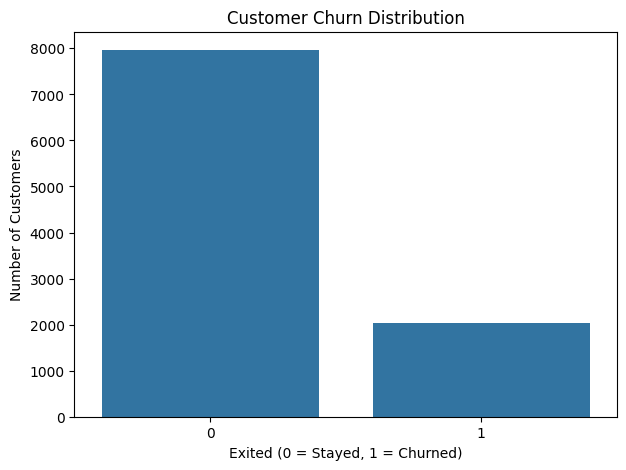

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Exited")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

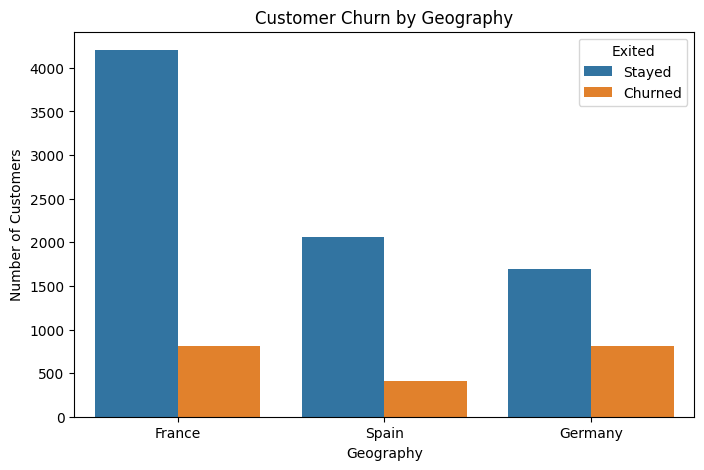

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Geography", hue="Exited")

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(title="Exited", labels=["Stayed", "Churned"])

plt.show()

In [ ]:
geography_churn = df.groupby("Geography")["Exited"].mean() * 100

print("Churn Rate by Geography:")
print(geography_churn.round(2))

Churn Rate by Geography:
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


In [ ]:
gender_churn = df.groupby("Gender")["Exited"].mean() * 100

print("Churn Rate by Gender:")
print(gender_churn.round(2))

Churn Rate by Gender:
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64


In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

NameError: name 'age_churn' is not defined

<Figure size 900x500 with 0 Axes>

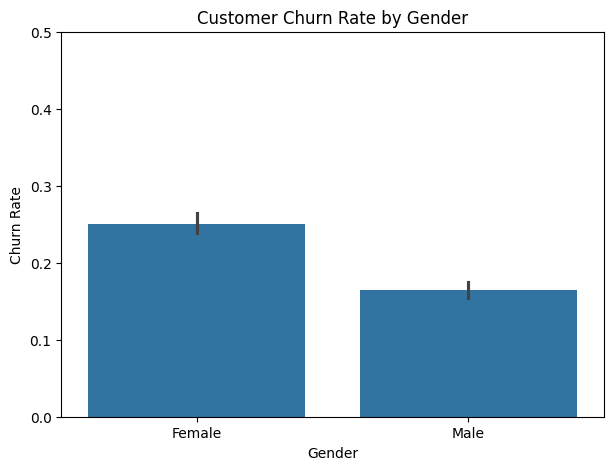

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Gender",
    y="Exited"
)

plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.5)

plt.show()

In [ ]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

# Calculate churn rate
age_churn = df.groupby("AgeGroup", observed=True)["Exited"].mean() * 100

print("Churn Rate by Age Group:")
print(age_churn.round(2))

Churn Rate by Age Group:
AgeGroup
18-25     7.47
26-35     8.50
36-45    19.62
46-55    50.57
56-65    48.32
66+      13.26
Name: Exited, dtype: float64


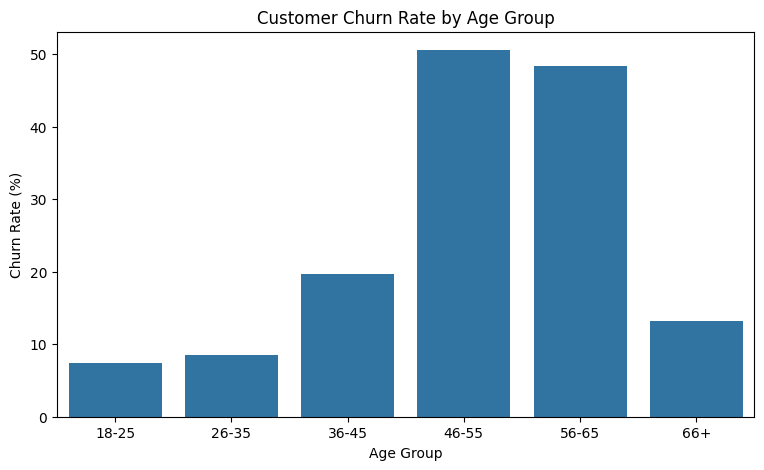

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [ ]:
credit_score_churn = df.groupby("Exited")["CreditScore"].mean()

print("Average Credit Score:")
print(credit_score_churn.round(2))

Average Credit Score:
Exited
0    651.85
1    645.35
Name: CreditScore, dtype: float64


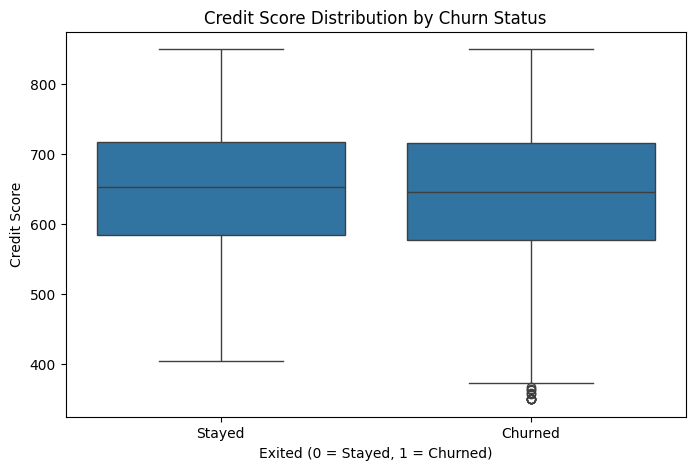

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="CreditScore"
)

plt.title("Credit Score Distribution by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Credit Score")
plt.xticks([0, 1], ["Stayed", "Churned"])

plt.show()

In [ ]:
balance_churn = df.groupby("Exited")["Balance"].mean()

print("Average Balance:")
print(balance_churn.round(2))

Average Balance:
Exited
0    72745.30
1    91108.54
Name: Balance, dtype: float64


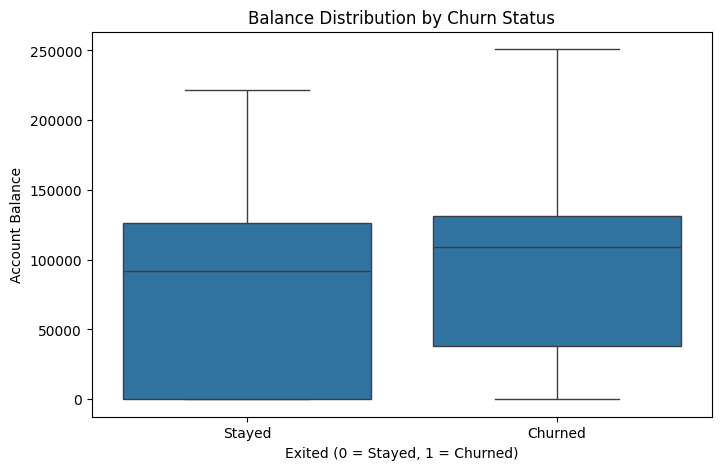

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Exited",
    y="Balance"
)

plt.title("Balance Distribution by Churn Status")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Account Balance")
plt.xticks([0, 1], ["Stayed", "Churned"])

plt.show()

In [ ]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100

print("Churn Rate by Active Membership:")
print(active_churn.round(2))

Churn Rate by Active Membership:
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


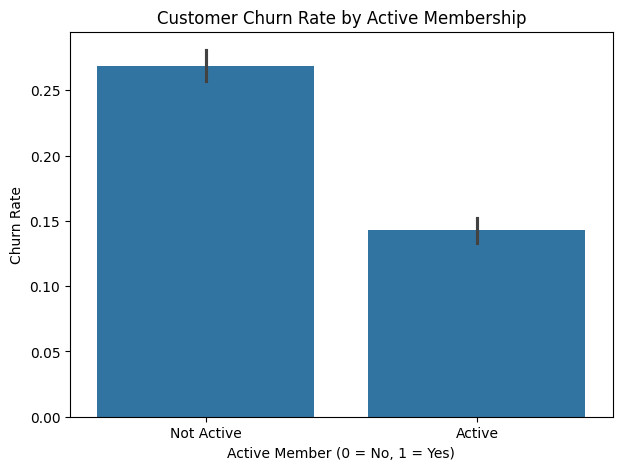

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="IsActiveMember",
    y="Exited"
)

plt.title("Customer Churn Rate by Active Membership")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")
plt.xticks([0, 1], ["Not Active", "Active"])

plt.show()

In [ ]:
product_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100

print("Churn Rate by Number of Products:")
print(product_churn.round(2))

Churn Rate by Number of Products:
NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64


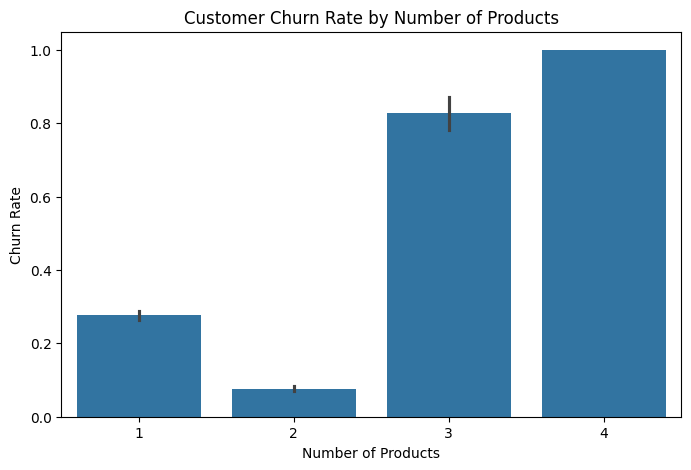

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="NumOfProducts",
    y="Exited"
)

plt.title("Customer Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")

plt.show()

In [ ]:
product_counts = df["NumOfProducts"].value_counts().sort_index()

print("Number of customers by product count:")
print(product_counts)

Number of customers by product count:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [ ]:
product_summary = df.groupby("NumOfProducts")["Exited"].agg(
    Customers="count",
    Churned="sum",
    Churn_Rate="mean"
)

product_summary["Churn_Rate"] = product_summary["Churn_Rate"] * 100

print(product_summary.round(2))

               Customers  Churned  Churn_Rate
NumOfProducts                                
1                   5084     1409       27.71
2                   4590      348        7.58
3                    266      220       82.71
4                     60       60      100.00


In [ ]:
from sklearn.model_selection import train_test_split

# Remove columns that should not be used for prediction
X = df.drop(
    columns=["RowNumber", "CustomerId", "Surname", "Exited", "AgeGroup"]
)

# Target variable
y = df["Exited"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Exited")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target:
Exited

Feature shape: (10000, 10)
Target shape: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training target distribution:
Exited
0    6370
1    1630
Name: count, dtype: int64

Testing target distribution:
Exited
0    1593
1     407
Name: count, dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical features
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

# Categorical features
categorical_features = [
    "Geography",
    "Gender"
]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Calculate metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("=" * 35)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
Accuracy : 0.8080
Precision: 0.5891
Recall   : 0.1867
F1-Score : 0.2836
ROC-AUC  : 0.7748

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



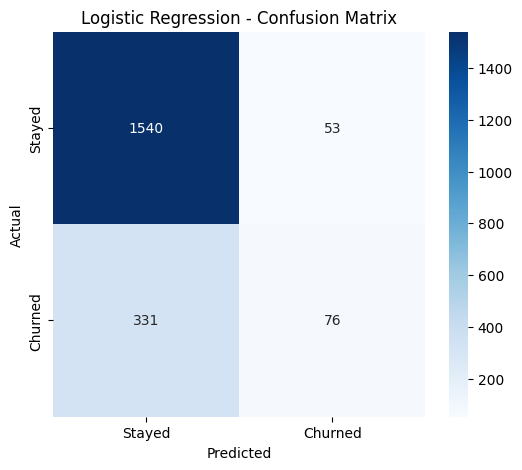

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("=" * 35)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.8590
Precision: 0.7660
Recall   : 0.4423
F1-Score : 0.5607
ROC-AUC  : 0.8532

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



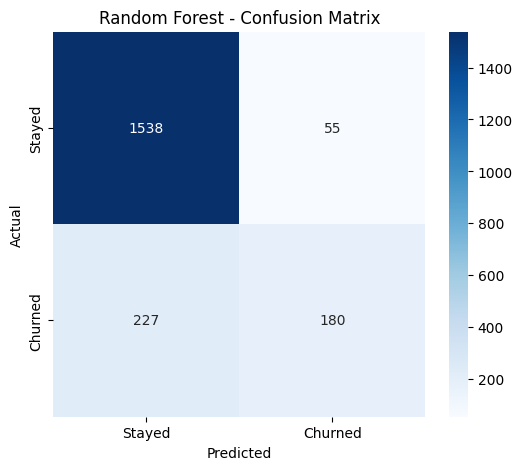

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [ ]:
y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting predictions generated successfully!")

Gradient Boosting predictions generated successfully!


In [ ]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Results")
print("=" * 35)
print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_auc_gb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy : 0.8705
Precision: 0.7937
Recall   : 0.4914
F1-Score : 0.6070
ROC-AUC  : 0.8697

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



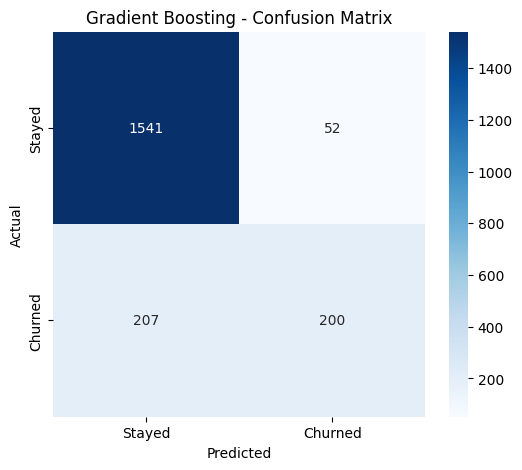

In [ ]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Gradient Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

# Save the complete trained pipeline
joblib.dump(
    gradient_boosting_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print("File exists:", os.path.exists("customer_churn_model.pkl"))
print("File size:", os.path.getsize("customer_churn_model.pkl"), "bytes")

File exists: True
File size: 270452 bytes


In [ ]:
from google.colab import files

files.download("customer_churn_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>